Importar dataset y librerias

In [35]:
import pandas as pd

#Import the dataset
dataset = 'Lorca_original.csv' 
                               
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data["Time"] = pd.to_datetime(data["Time"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["Time"].dt.month
data["day"] = data["Time"].dt.day
data["hour"] = data["Time"].dt.hour
data["minute"] = data["Time"].dt.minute

data.drop(columns=["Time"], inplace=True) #eliminamos la columna Time


print("Número de filas antes de filtrar: " + str(len(data)))

data = data.loc[data['Power_gen'].shift() != data['Power_gen']]#eliminamos filas con valores repetidos en power_gen de forma local,
                                                                         #ya que la medicion de power_gen no es sincrona con las demas variables


print("Número de filas tras filtrar: " + str(len(data)))

data.head(10)

Número de filas antes de filtrar: 47151
Número de filas tras filtrar: 2541


,temperature,windSpeed,solarRad,humedad,rain,Power_gen,pressure_sensor,pressure,month,day,hour,minute
0,12.0556,16.09340,7,70,0.0,0.000,446.901518,29.206,2,1,18,25
2681,17.6111,1.60934,664,38,0.0,11.512,385.049863,28.959,3,5,12,24
2693,18.5000,4.82803,682,37,0.0,0.000,385.366369,28.932,3,5,13,24
2992,12.7778,24.14020,473,46,0.0,8.651,395.484262,28.580,3,8,10,20
3005,14.4444,24.14020,594,41,0.0,11.375,394.392969,28.585,3,8,11,20
3018,15.1111,17.70280,701,39,0.0,13.378,394.329954,28.572,3,8,12,24
3030,16.0000,17.70280,726,34,0.0,13.874,457.276472,28.557,3,8,13,23
3042,15.6667,32.18690,255,34,0.0,5.101,394.938215,28.527,3,8,14,22
3054,16.2778,32.18690,666,33,0.0,9.273,392.266826,28.519,3,8,15,21
3066,16.5556,16.09340,445,32,0.0,9.279,394.856520,28.526,3,8,16,20


Separamos las variables predictoras y la variable objetivo 

In [36]:
#Eliminamos filas con valores NaN antes de dividir en train y test
df_clean = data.dropna(subset=['Power_gen'])
predictors = df_clean.drop(columns=['Power_gen'])
objective = df_clean['Power_gen']

Dividimos los datos en train y test

In [37]:
#Dividimos los datos en train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(predictors, objective, test_size=0.2, random_state=42) #20% para test

Calculamos los parámetros óptimos del modelo

In [14]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

params = {'max_depth': [2, 5, 9], #profundidad maxima del arbol
          'learning_rate': [0.01, 0.1, 0.2], #tasa de aprendizaje
          'n_estimators': [50, 100, 900], #numero de arboles
          'subsample': [0.6, 0.8, 1.0]} #datos para entrenamiento de cada arbol
pruebas = XGBRegressor()
grid = GridSearchCV(pruebas, params, scoring='neg_root_mean_squared_error', cv=2, verbose=2) #calculamos el valor optimo de los parametros
grid.fit(X_train, y_train)
print(grid.best_params_)


Fitting 2 folds for each of 81 candidates, totalling 162 fits
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.8; total time=   0.0s
[CV]

Creamos el modelo y entrenamos. Controlamos el sobreajuste.

In [38]:
from xgboost import XGBRegressor
xgb = XGBRegressor(learning_rate = 0.01, max_depth = 9, n_estimators = 900, subsample = 0.6) #aplicamos los parametros optimos obtenidos
xgb.fit(X_train, y_train)  #entrenamos el modelo

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)

Predicción y análisis

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("MAE: ", mean_absolute_error(y_test, y_pred)) #MAE = 0.345, lo que significa que las predicciones tienen un error medio de 0.345 unidades
print("MSE:", mse) #MSE = 0.854, lo que significa que las predicciones tienen un error cuadrado medio de 0.854 unidades
print("RMSE:", np.sqrt(mse)) #RMSE = 0.924, lo que significa que las predcciones tienen un valor de +-0.924 respecto a los valores reales
print("R²:", r2_score(y_test, y_pred)) #R^2 = 0.979, lo que significa que el modelo captura el 97,9% aproximadamente de la varianza de datos

MAE:  1.0339332097099858
MSE: 3.051739426887819
RMSE: 1.7469228451445185
R²: 0.9236629143968588


Obtener variables más importantes en la predicción

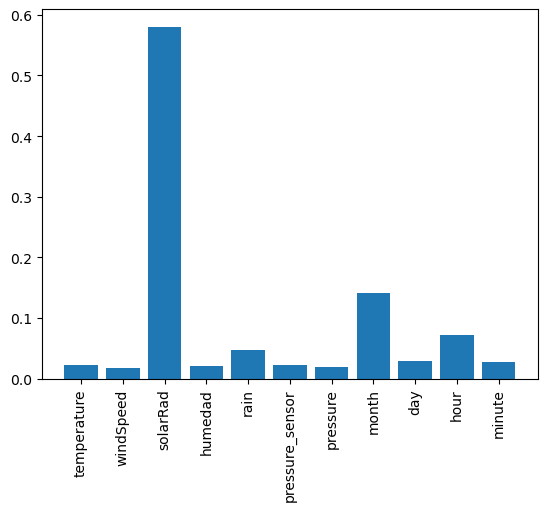

In [32]:
import matplotlib.pyplot as plt
plt.bar(X_train.columns, xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()


Comparativa predicción vs realidad

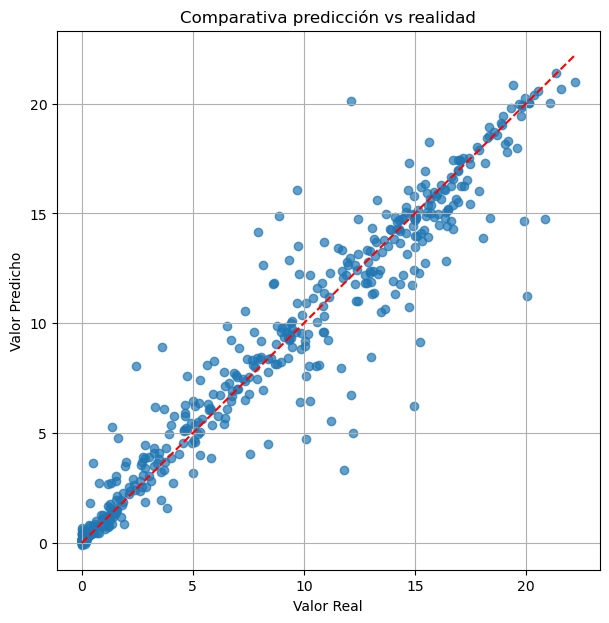

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()
